## Random Forest 

last update: 1.12.2025
data used: surrland_soil_sr_landsc_clim.csv

In [1]:
# import packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, auc # different metrics 
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor # RF model
from sklearn.tree import plot_tree # function to visualize a decision tree

In [2]:
# import data
data = pd.read_csv("surrland_soil_sr_landsc_clim.csv")
data.head()

,measurement.id,ma.id,study.id,control.id,latitude.decimal,longitude.decimal,country.new,treatment,crop.type.orig,crop.type.orig.grouped.small,...,silt.15.30cm.variance.5000,soc.15.30cm.centre,soc.15.30cm.variance.1000,soc.15.30cm.variance.2500,soc.15.30cm.variance.5000,soiltexture.centre,sr.amph,sr.birds,sr.mammals,sr.rept
0,-1.878136,D352,-0.666445,-0.139865,47.77,104.25,Mongolia,Erosion simulation,Wheat,Wheat,...,230.77,0.137690,497.53,1314.33,1788.69,Lo,-1.264196,-0.658380,-0.473882,-1.247330
1,-1.873112,D352,-0.677273,-0.139865,48.98,125.28,China,Erosion simulation,Maize,Maize,...,283.78,1.330121,645.45,1880.33,1751.08,ClLo,-0.889693,-0.623102,-0.263653,-1.171013
2,-1.871437,D352,-0.655617,-0.139865,48.98,125.28,China,Erosion simulation,Soybeans,Legumes,...,283.78,1.330121,645.45,1880.33,1751.08,ClLo,-0.889693,-0.623102,-0.263653,-1.171013
3,-1.869762,D352,-0.682688,-0.139865,53.43,-113.03,Canada,Erosion simulation,Wheat,Wheat,...,396.64,NaN,1614.53,3051.55,2477.83,Lo,-1.170570,-0.775973,-0.629482,-1.328519
4,-1.868087,D352,-0.704344,-0.139865,49.72,-112.80,Canada,Erosion simulation,Wheat,Wheat,...,506.23,NaN,14.89,30.74,89.30,SaClLo,-0.889693,-0.801608,-0.664143,-1.206736


In [3]:
# selected columns that were chosen to be tested as features predicting the pollination 
selected_columns = [
    "nat.hab.1000",
    "cropland.1000",
    "shannon.1000",
    "simpsonsevenness.1000",
    "am.richness.mean.1000",
    "ecm.richness.mean.1000",
    "sr.birds",
    "sr.mammals",
    "temp.avg.1970.2000",
    "prec.avg.1970.2000",
    "latitude.decimal",
    "longitude.decimal",
    'poll.dependent'
]
selected_data = data[selected_columns]
selected_data.shape # rows and columns number
selected_data.isna().sum()

nat.hab.1000               0
cropland.1000              0
shannon.1000               0
simpsonsevenness.1000      0
am.richness.mean.1000     72
ecm.richness.mean.1000    72
sr.birds                   0
sr.mammals                 0
temp.avg.1970.2000         0
prec.avg.1970.2000         0
latitude.decimal           0
longitude.decimal          0
poll.dependent             0
dtype: int64

In [4]:
selected_data = selected_data.dropna() # remove samples with missing values (we could also replace missing values by column averages)
selected_data.shape # check how many samples (rows) are there after removing missing values (originally there were 1384 samples)
selected_data.isna().sum()

nat.hab.1000              0
cropland.1000             0
shannon.1000              0
simpsonsevenness.1000     0
am.richness.mean.1000     0
ecm.richness.mean.1000    0
sr.birds                  0
sr.mammals                0
temp.avg.1970.2000        0
prec.avg.1970.2000        0
latitude.decimal          0
longitude.decimal         0
poll.dependent            0
dtype: int64

In [5]:
selected_data['poll.dependent'] == 0 # This is a mask to get not pollinated crops

0       True
1       True
2       True
4       True
6       True
        ... 
1379    True
1380    True
1381    True
1382    True
1383    True
Name: poll.dependent, Length: 1312, dtype: bool

In [6]:
mask_poll0 = selected_data['poll.dependent'] == 0 # save the mask as object mask_poll0
mask_poll0 # check the mask

0       True
1       True
2       True
4       True
6       True
        ... 
1379    True
1380    True
1381    True
1382    True
1383    True
Name: poll.dependent, Length: 1312, dtype: bool

In [7]:
mask_poll1 = selected_data['poll.dependent'] == 1 # save the mask as object mask_poll1
mask_poll1 # check the mask

0       False
1       False
2       False
4       False
6       False
        ...  
1379    False
1380    False
1381    False
1382    False
1383    False
Name: poll.dependent, Length: 1312, dtype: bool

In [8]:
mask_poll0.sum() , mask_poll1.sum() # total number of pollinated and not pollinated (= number of Trues in each mask) 
# The dataset is UNBALANCED!! 1224 not pollinated + 88 pollinated

(1224, 88)

In [9]:
# let's separate pollinated and not pollinated into two different dataframes
notpollinated = selected_data[mask_poll0]
pollinated = selected_data[mask_poll1]

In [10]:
# get (randomly) only 88 not pollinated crops (to achieve a balanced dataset)
notpollinated = notpollinated.sample(n = 88)

In [11]:
# final DataFrame with balanced pollinated and not pollinated, no missing values
data_cured = pd.concat([notpollinated, pollinated]) # pollinated and not pollinated are concatenated (row-wise) into DataFrame "data_cured" 

In [12]:
data_cured

,nat.hab.1000,cropland.1000,shannon.1000,simpsonsevenness.1000,am.richness.mean.1000,ecm.richness.mean.1000,sr.birds,sr.mammals,temp.avg.1970.2000,prec.avg.1970.2000,latitude.decimal,longitude.decimal,poll.dependent
777,0.813064,-0.288177,1.846602,2.078001,2.249277,-0.150450,0.492501,0.887331,1.274529,1.000021,23.75,109.31,0
10,-0.731861,1.207539,-1.387184,-1.048369,-1.030220,-0.418514,-0.611343,-0.440351,-2.159964,-1.051412,47.35,126.82,0
382,-0.126008,0.658092,0.169824,-0.228338,-0.576765,0.009112,-0.427781,-0.254988,-0.781792,-0.893189,35.20,107.67,0
448,1.418917,-0.959723,0.074008,-0.202712,0.306606,1.152851,-0.632627,-0.647189,-0.196616,0.884997,35.13,128.08,0
818,0.146626,-0.105028,0.912397,0.578881,0.802185,-0.713385,-0.351933,-0.807687,0.281005,-0.088543,31.57,120.63,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1326,1.055405,-0.532376,1.798694,1.949871,-1.418011,0.215904,-0.717176,-0.619686,-0.949506,-0.073449,42.46,-85.81,1
1327,2.145941,-1.631269,1.559155,1.257969,-2.716429,4.795968,-0.693658,-1.151287,-2.094337,-0.854154,62.79,16.75,1
1330,1.903600,-1.631269,-0.476933,-0.638354,-0.311630,0.312917,3.211482,3.332091,0.878942,4.647736,9.90,-83.67,1
1344,2.145941,-1.661794,0.409364,0.053548,-0.483843,2.761235,0.925595,2.684827,0.909933,0.850386,17.05,-92.87,1


In [13]:
# Let's shuffle the DataFrame
data_cured = data_cured.sample(frac = 1) # frac = fraction of rows to be shuffled (or "sampled"). Here, 1 = 100% of samples (rows)

In [14]:
data_cured

,nat.hab.1000,cropland.1000,shannon.1000,simpsonsevenness.1000,am.richness.mean.1000,ecm.richness.mean.1000,sr.birds,sr.mammals,temp.avg.1970.2000,prec.avg.1970.2000,latitude.decimal,longitude.decimal,poll.dependent
528,2.206526,-1.661794,-0.644611,-0.817736,0.485014,0.523539,2.734055,2.413187,1.504224,0.496986,-18.11,33.19,0
818,0.146626,-0.105028,0.912397,0.578881,0.802185,-0.713385,-0.351933,-0.807687,0.281005,-0.088543,31.57,120.63,0
1239,-0.428934,-1.661794,0.553088,-0.253964,-1.642260,1.281777,-0.638507,-0.013488,-0.996904,-1.185954,47.65,-117.42,0
730,-0.580397,0.749666,0.577042,0.361060,-1.370931,-0.570417,-0.428956,-0.262900,-0.923984,-1.643447,36.65,104.72,0
610,-0.822739,1.085439,-0.596703,-0.561476,-0.696943,-0.430003,-0.552547,-0.111444,-2.066992,-0.945236,45.87,128.81,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266,0.752479,-0.257652,1.894510,1.821741,-1.852882,1.248588,-0.752454,0.356108,-1.525568,0.412410,45.37,-63.40,0
1382,-0.095715,0.413894,0.050054,-0.215525,-1.255708,-0.145344,-0.705417,-0.320920,0.614610,-0.739130,33.45,-99.61,0
1046,-0.792446,1.054915,-0.452979,-0.587102,0.605192,-0.206616,0.022600,0.518112,0.649247,0.271363,29.88,106.37,0
1052,-0.792446,1.085439,-0.500887,-0.625541,0.613865,-0.169598,0.022600,0.518112,0.649247,0.271363,29.88,106.37,0


In [15]:
# the target vector will be the column "poll.dependent"
X = data_cured.drop(['poll.dependent'], axis = 1) # features are all columns except the target column
y = data_cured['poll.dependent'] # classes (=pollinated and not pollinated)

In [16]:
# check the features
X

,nat.hab.1000,cropland.1000,shannon.1000,simpsonsevenness.1000,am.richness.mean.1000,ecm.richness.mean.1000,sr.birds,sr.mammals,temp.avg.1970.2000,prec.avg.1970.2000,latitude.decimal,longitude.decimal
528,2.206526,-1.661794,-0.644611,-0.817736,0.485014,0.523539,2.734055,2.413187,1.504224,0.496986,-18.11,33.19
818,0.146626,-0.105028,0.912397,0.578881,0.802185,-0.713385,-0.351933,-0.807687,0.281005,-0.088543,31.57,120.63
1239,-0.428934,-1.661794,0.553088,-0.253964,-1.642260,1.281777,-0.638507,-0.013488,-0.996904,-1.185954,47.65,-117.42
730,-0.580397,0.749666,0.577042,0.361060,-1.370931,-0.570417,-0.428956,-0.262900,-0.923984,-1.643447,36.65,104.72
610,-0.822739,1.085439,-0.596703,-0.561476,-0.696943,-0.430003,-0.552547,-0.111444,-2.066992,-0.945236,45.87,128.81
...,...,...,...,...,...,...,...,...,...,...,...,...
1266,0.752479,-0.257652,1.894510,1.821741,-1.852882,1.248588,-0.752454,0.356108,-1.525568,0.412410,45.37,-63.40
1382,-0.095715,0.413894,0.050054,-0.215525,-1.255708,-0.145344,-0.705417,-0.320920,0.614610,-0.739130,33.45,-99.61
1046,-0.792446,1.054915,-0.452979,-0.587102,0.605192,-0.206616,0.022600,0.518112,0.649247,0.271363,29.88,106.37
1052,-0.792446,1.085439,-0.500887,-0.625541,0.613865,-0.169598,0.022600,0.518112,0.649247,0.271363,29.88,106.37


In [17]:
# check the target property. First column = index of the sample in the original(imported) DataFrame
y

528     0
818     0
1239    0
730     0
610     0
       ..
1266    0
1382    0
1046    0
1052    0
1259    1
Name: poll.dependent, Length: 176, dtype: int64

In [18]:
# we only use random_state to be able to split again X and y to generate precisely the same samples
# in X_train, y_train, etc.  Note that the function train_test_split() shuffles all rows of the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y) # stratify: get balanced subsets!

In [19]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape 

((140, 12), (36, 12), (140,), (36,))

In [20]:
(y_test == 0).sum() # you have precisely half of the test set for each class! (your test set is balanced)

18

In [21]:
# Let's preprocess the features
scaler = StandardScaler()
scaler.fit(X_train) #mean and std of each feature of X_train are stored inside object "scaler"
X_train_s = scaler.transform(X_train) # convert X_train into zero mean and unit variance
X_test_s = scaler.transform(X_test) # convert X_test into zero mean and unit variance

In [22]:
rf = RandomForestClassifier() # create the model (with 100 trees by default)
rf.fit(X_train_s, y_train) # train the model (optimize splitting parameters for all (100) trees)

pred = rf.predict(X_test_s) # perform predictions

acc = rf.score(X_test_s, y_test) # number of correct classifications / total number of classifications

print(f'accuracy: {acc*100:.2f}%')

accuracy: 80.56%


In [23]:
report = classification_report(y_test, pred) 
print(report) # without the 'stratify' parameter used during dataset splitting, the 'support' below would be different for both classes

              precision    recall  f1-score   support

           0       0.82      0.78      0.80        18
           1       0.79      0.83      0.81        18

    accuracy                           0.81        36
   macro avg       0.81      0.81      0.81        36
weighted avg       0.81      0.81      0.81        36



In [24]:
# check which features are more important
feature_names = X.columns # ".columns" attribute of DataFrame object X has the names of all columns
importances = rf.feature_importances_ # get feature importances from the trained model 
# (impurity is computed as the mean and standard deviation of accumulation of the impurity decrease within each decision tree)

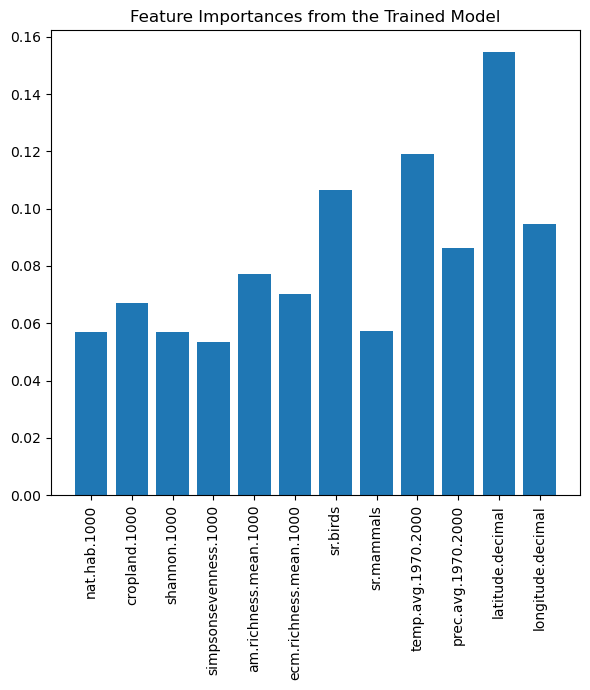

In [31]:
plt.figure(figsize=(6, 7)) 
plt.bar(feature_names, height=importances)
plt.xticks(rotation=90);
plt.title("Feature Importances from the Trained Model", fontsize=12);
plt.tight_layout(); 
plt.savefig('20251130_importance_poll_selected_columns.jpeg', dpi=600) # uncomment this line to save your tree


In [26]:
# Let's decrease the maximum depth of the tree to facilitate visualization:
rf = RandomForestClassifier(max_depth=3)
rf.fit(X_train_s, y_train)

RandomForestClassifier(max_depth=3)

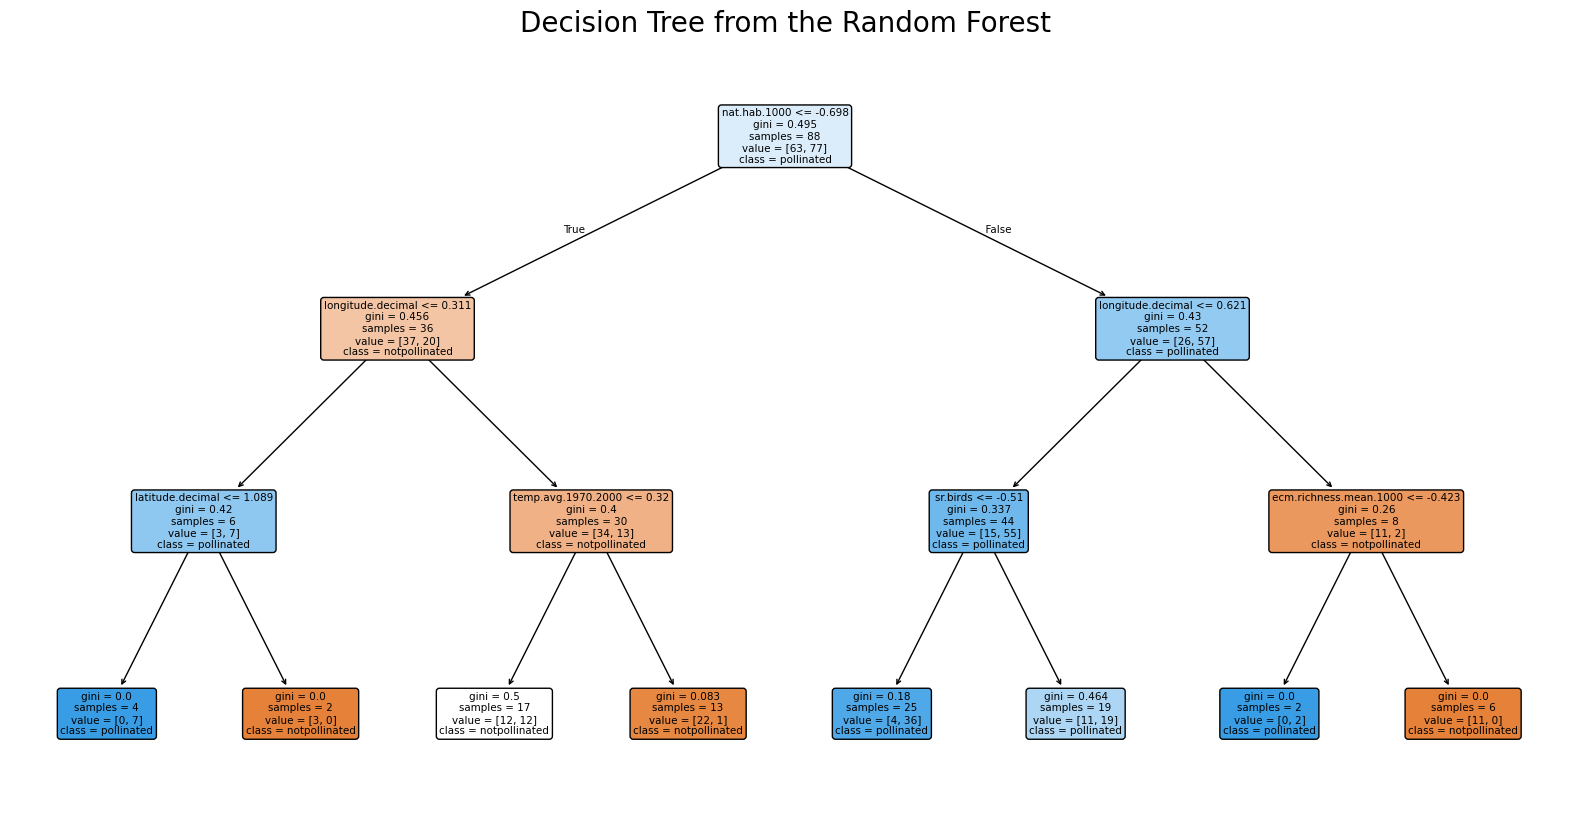

In [27]:
tree = rf.estimators_[0] # Let's visualize the first tree

plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=feature_names,  # List of your feature names
    class_names=['notpollinated', 'pollinated'],      # List of your class labels
    filled=True,
    rounded=True
)
plt.title("Decision Tree from the Random Forest", fontsize=20);
plt.savefig('20251130_poll_selected_columns.jpeg', dpi=600) # uncomment this line to save your tree